##### 第一次讀書會專案：針對PTT軍事版以及八卦版中對於美國出兵伊朗相關文章之情緒分析
##### 組別：Group_3
##### 組員：
* M144020008 洪宏林
* M144020017 陳姿佑
* M144020019 顏志豪
* M144020058 黄鈞浩
* M144020002 吳俊廷
* M144020028 白茗仁
* M144020061 黃博章
* B124020008 李怡君
##### 詳細檔案可到：https://github.com/Sylvan945/Social_Network_Analysis_Group_3

##### 專案動機：
1.	國際危機下的社會： 2026年3月初，伊朗局勢成為國際焦點，短短 20 天內在 PTT 雙看板（八卦版、戰爭版）湧現逾兩千篇文章。面對遠在天邊的中東衝突，台灣網友的反應並非漠不關心，而是投射了強烈的情緒。透過情緒分析，我們能捕捉到這些隱藏在文字背後的社會集體心理狀態。

2.	辨識「客觀事實」與「主觀感受」的落差： 傳統新聞媒體多以客觀角度報導戰況與國際角力，但 PTT 論壇則充滿了網民的主觀感受（如：對第三次世界大戰的恐慌、對油價飆漲的焦慮、或是用黑色幽默與反串來面對危機）。分析這些文本情緒，有助於我們了解未經修飾的真實民意。

3.	社群同溫層的情緒渲染： PTT 是一個高度互動的匿名社群，特定事件往往會引發情緒的快速傳染與極化。了解網民在面對戰爭議題時，是傾向理性分析、恐慌焦慮，還是嘲諷看戲，對於研究網路輿論傳播與群眾心理具有高度價值。

##### 1.資料介紹
##### 資料來源：
* Python爬蟲收集PTT平台上與《伊朗》相關的文章
* 來源：戰爭版/八卦版
* 關鍵字：伊朗
* 時間： 2026/03/01~2026/03/20
* 資料筆數：共 2080篇文章




#### 2.1 初始設定

In [2]:
import pandas as pd
import jieba
import jieba.posseg as pseg
import re
from wordcloud import WordCloud
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import os
import requests

In [ ]:
if not os.path.exists('font.ttf'):
    !wget -O font.ttf https://github.com/google/fonts/raw/main/ofl/notosanstc/NotoSansTC%5Bwght%5D.ttf

font_path = './font.ttf'
fm.fontManager.addfont(font_path)
prop = fm.FontProperties(fname=font_path)

plt.rcParams['font.family'] = 'Noto Sans TC'
# 確保圖表中的負號 (-) 能正常顯示
plt.rcParams['axes.unicode_minus'] = False
print("字體設定完成！")

In [4]:
#or system font
system_font = r"C:/Windows/Fonts/msjh.ttc"
prop = fm.FontProperties(fname=system_font)
plt.rcParams['font.sans-serif']=['Microsoft JhengHei']

#### 2.2 讀取與基本清洗

In [5]:
# 讀取檔案
df = pd.read_csv('../data/ptt_iran_20260301_0320_new.csv')
clear_df = df.copy() # 複製一份資料進行清洗，保留原始資料以供對照

# 定義並去除分析時用不到的系統與詮釋資料欄位
drop_cols = ['system_id', 'artCatagory', 'artUrl', 'artPoster', 'insertedDate','artComment','dataSource']
clear_df.drop(drop_cols, axis=1, inplace=True, errors='ignore')

# 移除內文 (artContent) 為空值的資料行
clear_df.dropna(subset=['artContent'], inplace=True)

clear_df.head()

,artTitle,artDate,artContent
0,Re: [情報] 美軍一架F-35在伊朗執行任務臨時迫降,2026/3/20 23:02,https://x.com/i/status/2034972525222838351\n\n...
1,[新聞] 川普考慮奪取Kharg Island 迫使伊朗開放,2026/3/20 18:41,原文來源：\nhttps://www.axios.com/2026/03/20/iran-i...
2,Re: [分享] 川普以珍珠港事件來形容打伊朗的出其不意,2026/3/20 17:17,※ 引述《andyken (碎夢殘刀)》之銘言：\n: https://x.com/Jour...
3,[情報] Glenn Diesen訪問伊朗德黑蘭教授,2026/3/20 14:57,https://youtu.be/AYLACkCWXRA?si=O7evaTpTVNG4kI...
5,[新聞] 伊朗襲擊約旦河西岸 3巴勒斯坦人喪命,2026/3/20 11:55,原文來源：\nhttps://www.cna.com.tw/news/aopl/202603...


##### 2.3 PTT 專屬進階文字清理

In [6]:

def clean_ptt_text(text):
    """清理 PTT 文章中常見的雜訊 (網址、簽名檔、引言等)"""
    text = str(text)
    text = re.sub(r'https?://\S+|www\.\S+', '', text)
    # 移除文末的 PTT 發信站簽名檔
    text = re.sub(r'※ 發信站: 批踢踢實業坊\(ptt\.cc\).*', '', text)
    # 移除回文時常見的引述宣告
    text = re.sub(r'引述《.*》之銘言', '', text)
    # 移除標題標籤，例如 [新聞]、[爆卦]
    text = re.sub(r'\[.*?\]', '', text)
    # 移除純英文和數字 (可過濾掉推文 ID、XD、網址殘留)
    text = re.sub(r'[a-zA-Z0-9]+', '', text)
    text = re.sub(r'\n+', '。', text)
    return text

# 將清理函式套用到內文欄位
clear_df['sentence'] = clear_df['artContent'].apply(clean_ptt_text)

# 斷句：利用標點符號將整篇文章切分成一句一句的短句
clear_df['sentence'] = clear_df['sentence'].str.split(r"[,，。！!？?]+")
# explode 會將串列中的句子拆解成多列，重置索引
sent_df = clear_df.explode('sentence').reset_index(drop=True)
# 濾除只有 1 個字或全空的無效短句
sent_df = sent_df[sent_df["sentence"].str.len() > 1]

print("\n=== 文字清理與斷句完成 ===")
print(f"目前總共切出了 {len(sent_df)} 句短句準備進行斷詞！")

sent_df


=== 文字清理與斷句完成 ===
目前總共切出了 81743 句短句準備進行斷詞！


,artTitle,artDate,artContent,sentence
1,Re: [情報] 美軍一架F-35在伊朗執行任務臨時迫降,2026/3/20 23:02,https://x.com/i/status/2034972525222838351\n\n...,報導
2,Re: [情報] 美軍一架F-35在伊朗執行任務臨時迫降,2026/3/20 23:02,https://x.com/i/status/2034972525222838351\n\n...,迫降的-飛行員有破片輕傷
3,Re: [情報] 美軍一架F-35在伊朗執行任務臨時迫降,2026/3/20 23:02,https://x.com/i/status/2034972525222838351\n\n...,受損的-進行硬著陸
4,Re: [情報] 美軍一架F-35在伊朗執行任務臨時迫降,2026/3/20 23:02,https://x.com/i/status/2034972525222838351\n\n...,短期內不能作戰
5,Re: [情報] 美軍一架F-35在伊朗執行任務臨時迫降,2026/3/20 23:02,https://x.com/i/status/2034972525222838351\n\n...,另外網路上流傳據稱是伊朗防空系統的影片
...,...,...,...,...
85368,[問卦] 以色列說伊朗精神導師哈米尼已身亡,2026/3/1 00:01,https://i.imgur.com/FrMBP3e.jpeg\n\n以色列電視台12頻道...,才打幾小時說
85369,[問卦] 以色列說伊朗精神導師哈米尼已身亡,2026/3/1 00:01,https://i.imgur.com/FrMBP3e.jpeg\n\n以色列電視台12頻道...,--
85370,[問卦] 以色列說伊朗精神導師哈米尼已身亡,2026/3/1 00:01,https://i.imgur.com/FrMBP3e.jpeg\n\n以色列電視台12頻道...,※ 文章網址:
85371,[問卦] 以色列說伊朗精神導師哈米尼已身亡,2026/3/1 00:01,https://i.imgur.com/FrMBP3e.jpeg\n\n以色列電視台12頻道...,※ 編輯: (... 臺灣)


##### 2.4 斷詞與詞性篩選

In [7]:
# 初始化 jieba 的繁體中文大字典
jieba.set_dictionary('../dict/dict.txt')

# 建立領域專屬詞庫 (強制 jieba 將這些字視為一個詞，不要切碎)
# 針對本次「伊朗議題」手動加入關鍵字
custom_words = ['防衛隊', '革命衛隊', '無人機', '核設施', '哈瑪斯', '真主黨', '中東', '大馬士革', '德黑蘭','哈梅內伊']
for w in custom_words:
    jieba.add_word(w)

# 定義我們想保留的詞性 (主要是名詞系列，這樣文字雲會比較有具體意義)
# n:一般名詞, nr:人名, ns:地名, nt:機構名, nz:其他專有名詞, vn:名動詞
allowed_flags = ['n', 'nr', 'ns', 'nt', 'nz', 'vn']


"""進行斷詞並根據詞性過濾"""
def get_keywords(text):
    words = pseg.cut(text)
    # 列表推導式過濾條件：1. 詞長大於等於 2 個字
    return [w.word for w in words if len(w.word) >= 2 and w.flag in allowed_flags]

# 執行斷詞與過濾
word_df = sent_df.assign(word=sent_df['sentence'].apply(get_keywords)).explode('word').dropna(subset=['word'])

#  檢查的程式碼
print("\n=== 斷詞與詞性篩選完成 ===")
print(f"從原本的短句中，總共萃取出 {len(word_df)} 個符合條件的詞彙！")

print("\n--- 隨機抽查 10 個保留的詞彙 ---")
print(word_df['word'].sample(10).to_string(index=False))

print("\n--- 快速檢查目前出現最多次的 Top 15 詞彙 ---")
# 透過 value_counts() 快速抓出最高頻的詞
print(word_df['word'].value_counts().head(15))
word_df

Building prefix dict from d:\學校東西\研究所\社媒\groupwork1\dict\dict.txt ...
Loading model from cache C:\Users\h0848\AppData\Local\Temp\jieba.uf4066f7283e6c3dd151d8d548cc5397a.cache
Loading model cost 0.310 seconds.
Prefix dict has been built successfully.



=== 斷詞與詞性篩選完成 ===
從原本的短句中，總共萃取出 53464 個符合條件的詞彙！

--- 隨機抽查 10 個保留的詞彙 ---
  伊朗
 本雅明
  合法
  伊朗
  防空
 但川寶
 代理人
 路透社
  格齊
  消耗

--- 快速檢查目前出現最多次的 Top 15 詞彙 ---
伊朗     11278
文章      2252
以色列     2177
政府       764
石油       594
基地       590
能源       485
能力       418
人士       415
世界       409
防空       409
全球       406
消息       402
武器       358
人民       345
Name: word, dtype: int64


,artTitle,artDate,artContent,sentence,word
2,Re: [情報] 美軍一架F-35在伊朗執行任務臨時迫降,2026/3/20 23:02,https://x.com/i/status/2034972525222838351\n\n...,迫降的-飛行員有破片輕傷,破片
5,Re: [情報] 美軍一架F-35在伊朗執行任務臨時迫降,2026/3/20 23:02,https://x.com/i/status/2034972525222838351\n\n...,另外網路上流傳據稱是伊朗防空系統的影片,伊朗
5,Re: [情報] 美軍一架F-35在伊朗執行任務臨時迫降,2026/3/20 23:02,https://x.com/i/status/2034972525222838351\n\n...,另外網路上流傳據稱是伊朗防空系統的影片,防空
5,Re: [情報] 美軍一架F-35在伊朗執行任務臨時迫降,2026/3/20 23:02,https://x.com/i/status/2034972525222838351\n\n...,另外網路上流傳據稱是伊朗防空系統的影片,影片
6,Re: [情報] 美軍一架F-35在伊朗執行任務臨時迫降,2026/3/20 23:02,https://x.com/i/status/2034972525222838351\n\n...,我不知道真假,真假
...,...,...,...,...,...
85359,[問卦] 愛潑斯坦被戳的小孩跟被炸死的伊朗哪個慘,2026/3/1 00:06,如題，\n\n有人說艾波斯坦給小孩錢，\n還有花錢請人生嬰兒來吃，\n很邪惡。\n\n\n可...,卻察覺到別人都看不起你資格的眼神在應付你,眼神
85365,[問卦] 以色列說伊朗精神導師哈米尼已身亡,2026/3/1 00:01,https://i.imgur.com/FrMBP3e.jpeg\n\n以色列電視台12頻道...,以色列電視台頻道快訊說,以色列
85366,[問卦] 以色列說伊朗精神導師哈米尼已身亡,2026/3/1 00:01,https://i.imgur.com/FrMBP3e.jpeg\n\n以色列電視台12頻道...,伊朗精神導師哈米尼已身亡,伊朗
85366,[問卦] 以色列說伊朗精神導師哈米尼已身亡,2026/3/1 00:01,https://i.imgur.com/FrMBP3e.jpeg\n\n以色列電視台12頻道...,伊朗精神導師哈米尼已身亡,精神


##### 2.5 最終停用字過濾

In [8]:
# 讀取停用字檔
try:
    with open('/content/stopwords.txt', 'r', encoding='utf-8') as f:
        stopwords = set([line.strip() for line in f])
except FileNotFoundError:
    stopwords = set()

# 手動補充停用字
stopwords_manual = {"新聞", "文章", "標題", "報導", "八卦", "看板", "作者", "時間", "來源", "內容", "媒體", "情況", "問題", "如題", "原因","網址"}
stopwords.update(stopwords_manual) # 將手動名單加入停用字集合

# 執行最後過濾：只保留「不在」停用字集合裡的詞彙
noStop_df = word_df[~word_df['word'].isin(stopwords)]

##### 2.6 同義詞替換

In [9]:
synonyms = {
    '哈梅內伊': '哈米尼',
    'Donald Trump': '川普',
    '阿川': '川普',
    '川皇': '川普'
}
noStop_df['word'] = noStop_df['word'].replace(synonyms)

c:\Users\h0848\anaconda3\envs\LabLearning\lib\site-packages\ipykernel_launcher.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  import sys


##### 2.7 計算詞頻與繪圖

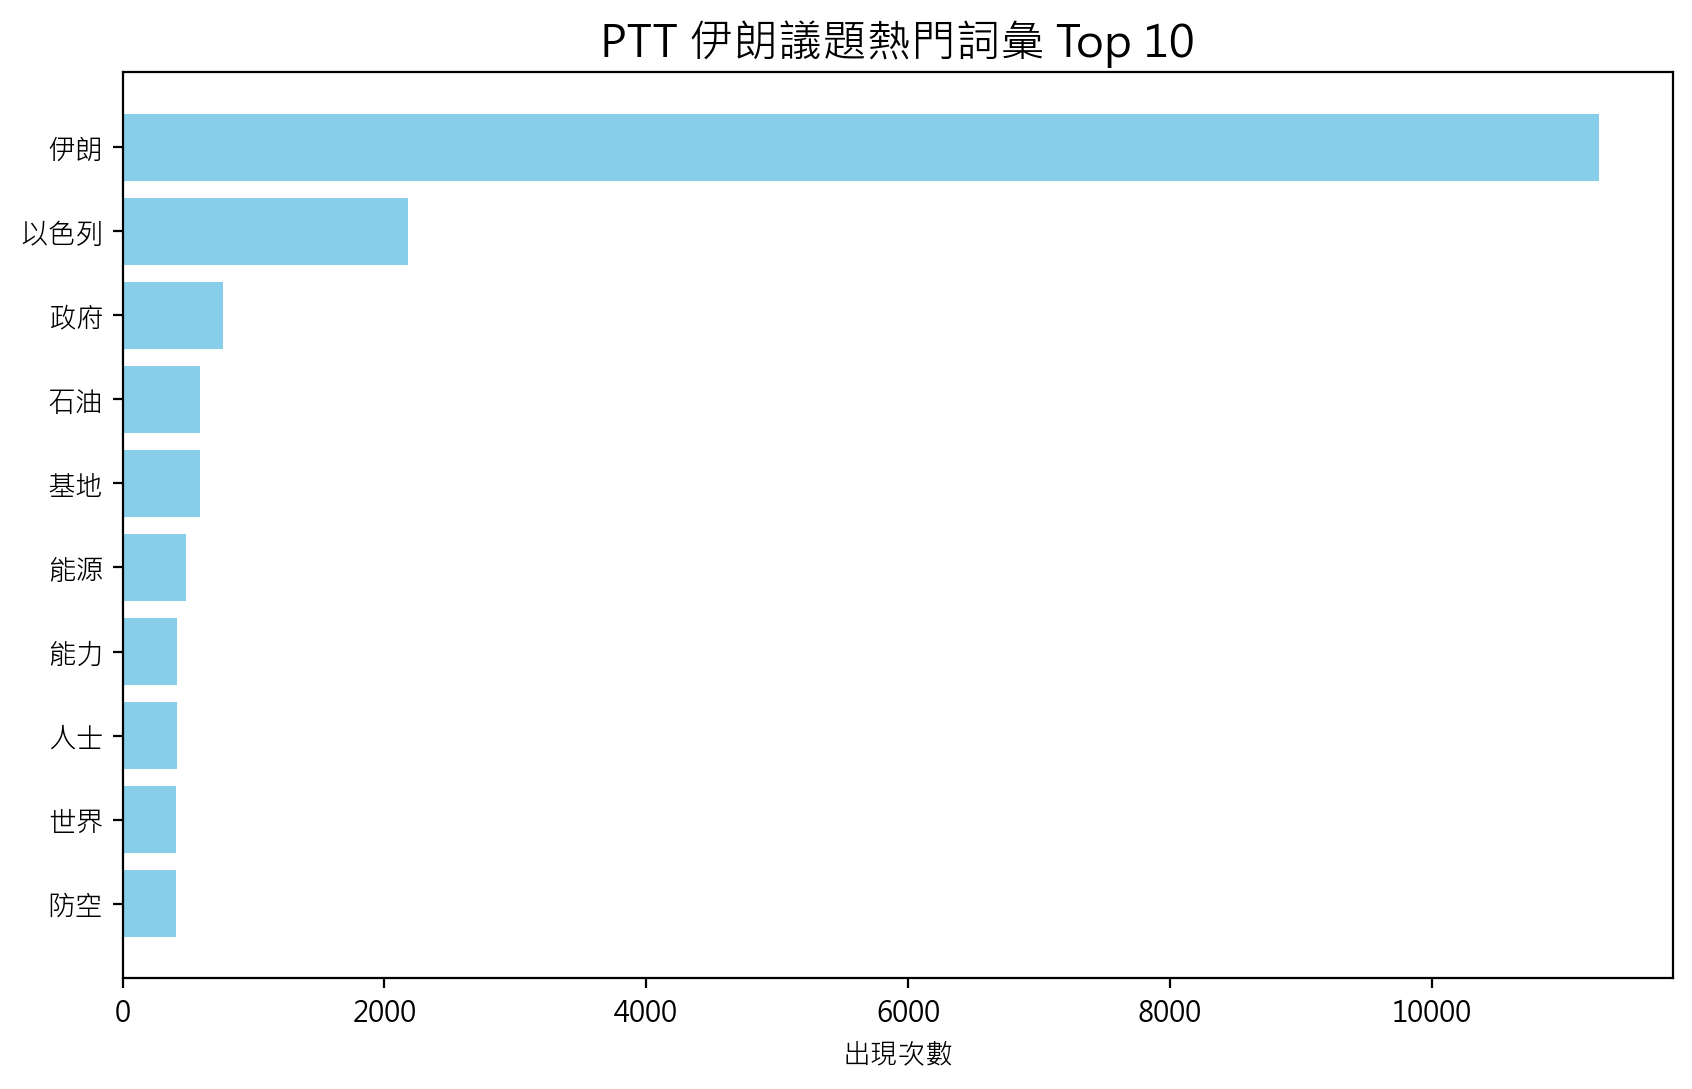

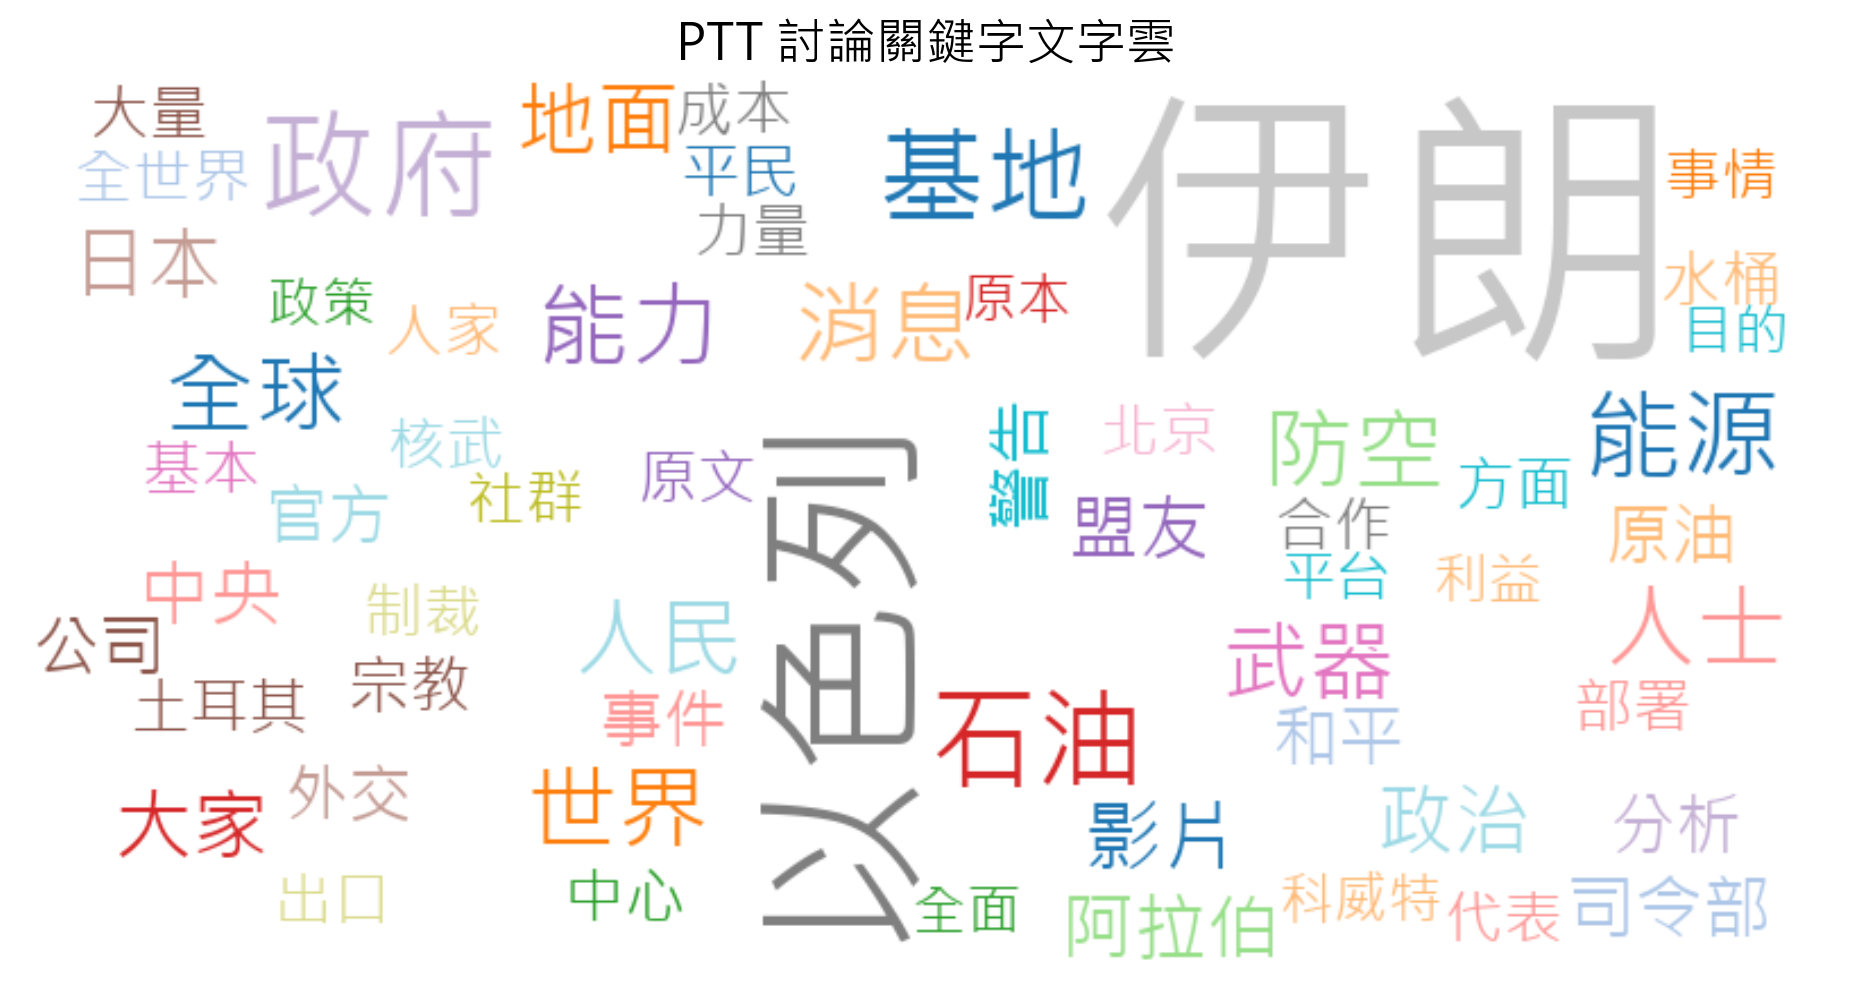


--- 檢查前 20 名高頻詞 ---
   word  count
0    伊朗  11278
1   以色列   2177
2    政府    764
3    石油    594
4    基地    590
5    能源    485
6    能力    418
7    人士    415
8    世界    409
9    防空    409
10   全球    406
11   消息    402
12   武器    358
13   人民    345
14   地面    331
15   政治    289
16   影片    286
17   大家    286
18   日本    270
19  阿拉伯    259


In [10]:
freq_df_nostop = noStop_df['word'].value_counts().reset_index()
freq_df_nostop.columns = ['word', 'count']

freq_dict = freq_df_nostop.set_index('word').to_dict()['count']

# 繪製長條圖
top_10_words = freq_df_nostop.head(10)
plt.figure(figsize=(10, 6), dpi=200)
plt.barh(top_10_words['word'], top_10_words['count'], color='skyblue')
plt.gca().invert_yaxis()
plt.title("PTT 伊朗議題熱門詞彙 Top 10", fontproperties=prop, fontsize=16)
plt.xlabel("出現次數", fontproperties=prop)
plt.show()
system_font = "C:/Windows/Fonts/msjh.ttc"
# 繪製文字雲
wordcloud = WordCloud(
    background_color='white',
    width=800,
    height=400,
    font_path=system_font,
    max_words=60,
    colormap='tab20'
)
wordcloud.generate_from_frequencies(freq_dict)

plt.figure(figsize=(12, 6), dpi=200)
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title("PTT 討論關鍵字文字雲", fontproperties=prop, fontsize=18)
plt.show()

# 印出前20名檢查
print("\n--- 檢查前 20 名高頻詞 ---")
print(freq_df_nostop.head(20))

##### 3.1 趨勢圖

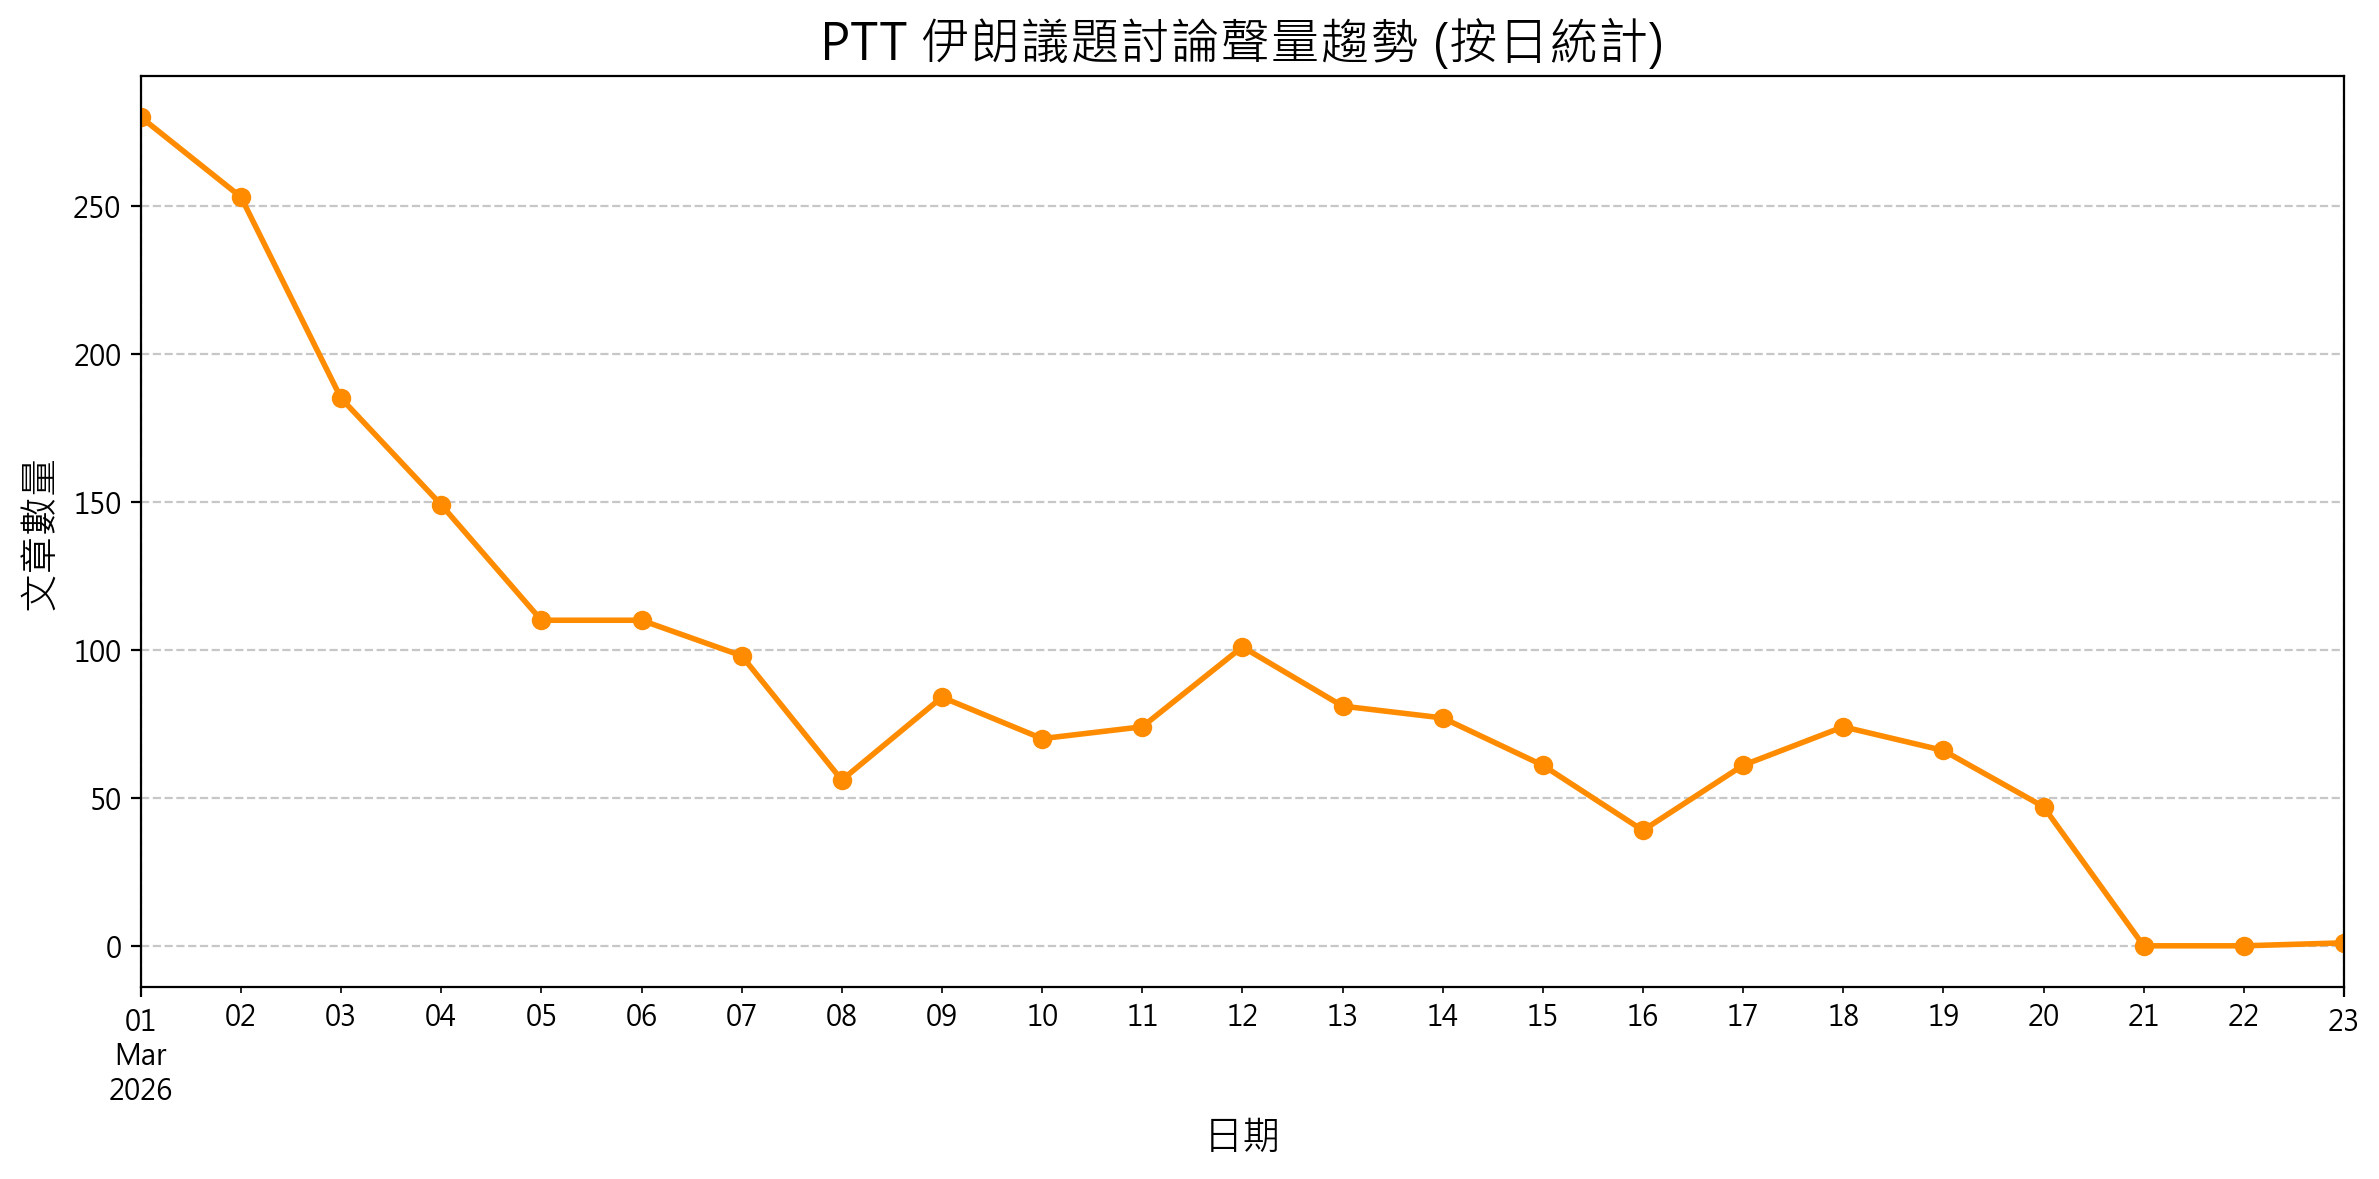

In [11]:
df['artDate'] = pd.to_datetime(df['artDate'], errors='coerce')
# 依照天來統計文章數量
daily_counts = df.resample('D', on='artDate').size()

#畫圖
plt.figure(figsize=(12, 6), dpi=200)
daily_counts.plot(kind='line', marker='o', color='darkorange', linewidth=2)

plt.title("PTT 伊朗議題討論聲量趨勢 (按日統計)", fontproperties=prop, fontsize=18)
plt.xlabel("日期", fontproperties=prop, fontsize=14)
plt.ylabel("文章數量", fontproperties=prop, fontsize=14)

plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

##### 3.2 正負向情緒分析-每日情緒走勢

In [12]:
#load LIWC
def load_liwc(file_path):
    with open(file_path, 'r', encoding='utf-8-sig') as f:
        content = f.read()
        words = [w.strip() for w in content.split(',') if w.strip()]
    return set(words)

#載入
pos_words = load_liwc('../dict/liwc/positive.txt')
neg_words = load_liwc('../dict/liwc/negative.txt')

#建立對照表
pos_df = pd.DataFrame({'word': list(pos_words), 'sentiment_label': 1})
neg_df = pd.DataFrame({'word': list(neg_words), 'sentiment_label': -1})
liwc_full_dict = pd.concat([pos_df, neg_df], ignore_index=True)

In [13]:
word_df['word'] = word_df['word'].astype(str).str.strip()
liwc_full_dict['word'] = liwc_full_dict['word'].astype(str).str.strip()
#merge
ptt_liwc_df = pd.merge(
    word_df[['artTitle', 'artDate', 'artContent', 'sentence', 'word']], 
    liwc_full_dict, 
    on='word', 
    how="left"
)

#處理未對應到的詞
ptt_liwc_df['sentiment_label'] = ptt_liwc_df['sentiment_label'].fillna(0)
print(ptt_liwc_df[ptt_liwc_df['sentiment_label'] != 0][['word', 'sentiment_label']].head())

    word  sentiment_label
165   合法              1.0
275   和平              1.0
300   合理              1.0
336   警告             -1.0
370   合法              1.0


In [14]:
# 計算每篇文章的總情緒分數 (加總該文章所有詞的標籤值)
article_sentiment = ptt_liwc_df.groupby(['artTitle', 'artDate'])['sentiment_label'].sum().reset_index()

# 重新命名欄位以便識別
article_sentiment.rename(columns={'sentiment_label': 'article_score'}, inplace=True)

article_sentiment['artDate'] = pd.to_datetime(article_sentiment['artDate'])

# 計算每日平均情緒
daily_sentiment = article_sentiment.resample('D', on='artDate')['article_score'].mean()
daily_sentiment 

artDate
2026-03-01   -0.140288
2026-03-02   -0.059289
2026-03-03    0.064865
2026-03-04   -0.268456
2026-03-05    0.136364
2026-03-06    0.148148
2026-03-07   -0.051020
2026-03-08   -0.071429
2026-03-09   -0.107143
2026-03-10   -0.014286
2026-03-11    0.027027
2026-03-12   -0.029703
2026-03-13   -0.098765
2026-03-14   -0.220779
2026-03-15    0.262295
2026-03-16   -0.102564
2026-03-17    0.213115
2026-03-18   -0.013514
2026-03-19    0.075758
2026-03-20   -0.255319
Freq: D, Name: article_score, dtype: float64

c:\Users\h0848\anaconda3\envs\LabLearning\lib\site-packages\matplotlib\backends\backend_agg.py:238: RuntimeWarning: Glyph 8722 missing from current font.
  font.set_text(s, 0.0, flags=flags)
c:\Users\h0848\anaconda3\envs\LabLearning\lib\site-packages\matplotlib\backends\backend_agg.py:201: RuntimeWarning: Glyph 8722 missing from current font.
  font.set_text(s, 0, flags=flags)


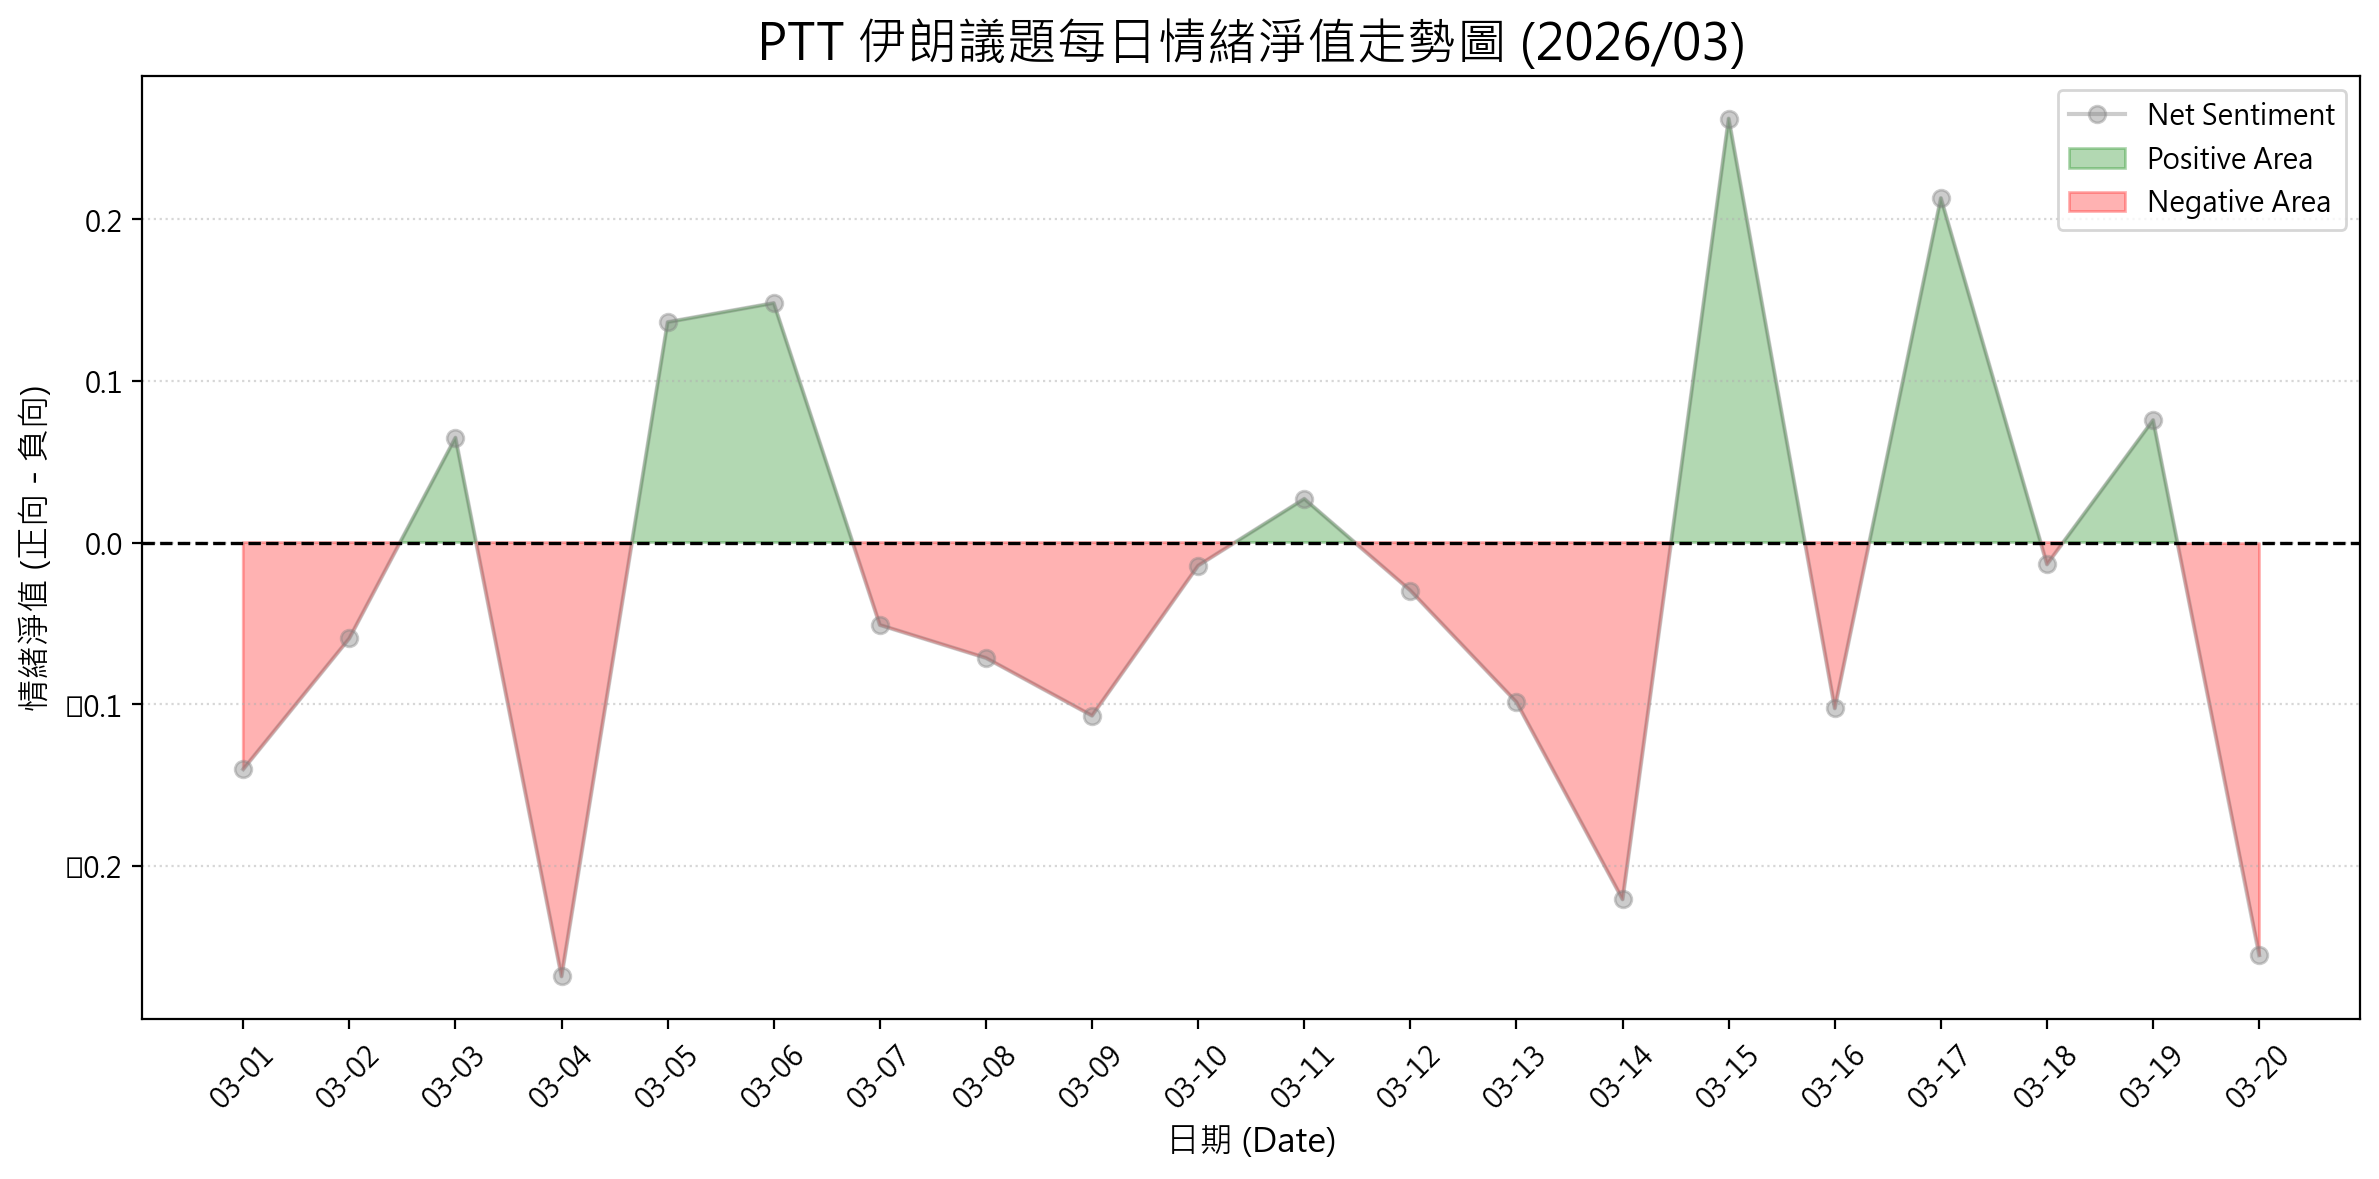

In [15]:
plt.figure(figsize=(12, 6), dpi=200)

plot_data = daily_sentiment.fillna(0)

plt.plot(plot_data.index, plot_data.values, 
         marker='o', linestyle='-', color='gray', alpha=0.4, label='Net Sentiment')

plt.fill_between(plot_data.index, 0, plot_data.values, 
                 where=(plot_data.values >= 0), 
                 color='green', alpha=0.3, interpolate=True, label='Positive Area')

plt.fill_between(plot_data.index, 0, plot_data.values, 
                 where=(plot_data.values < 0), 
                 color='red', alpha=0.3, interpolate=True, label='Negative Area')

plt.axhline(0, color='black', linewidth=1.2, linestyle='--')

plt.title("PTT 伊朗議題每日情緒淨值走勢圖 (2026/03)", fontproperties=prop, fontsize=18)
plt.xlabel("日期 (Date)", fontproperties=prop, fontsize=12)
plt.ylabel("情緒淨值 (正向 - 負向)", fontproperties=prop, fontsize=12)

plt.xticks(plot_data.index, [d.strftime('%m-%d') for d in plot_data.index], rotation=45)
plt.grid(True, axis='y', linestyle=':', alpha=0.5)

plt.legend(prop=prop, loc='upper right')

plt.tight_layout()
plt.show()

##### 3.3 正負向情緒分析-折線圖

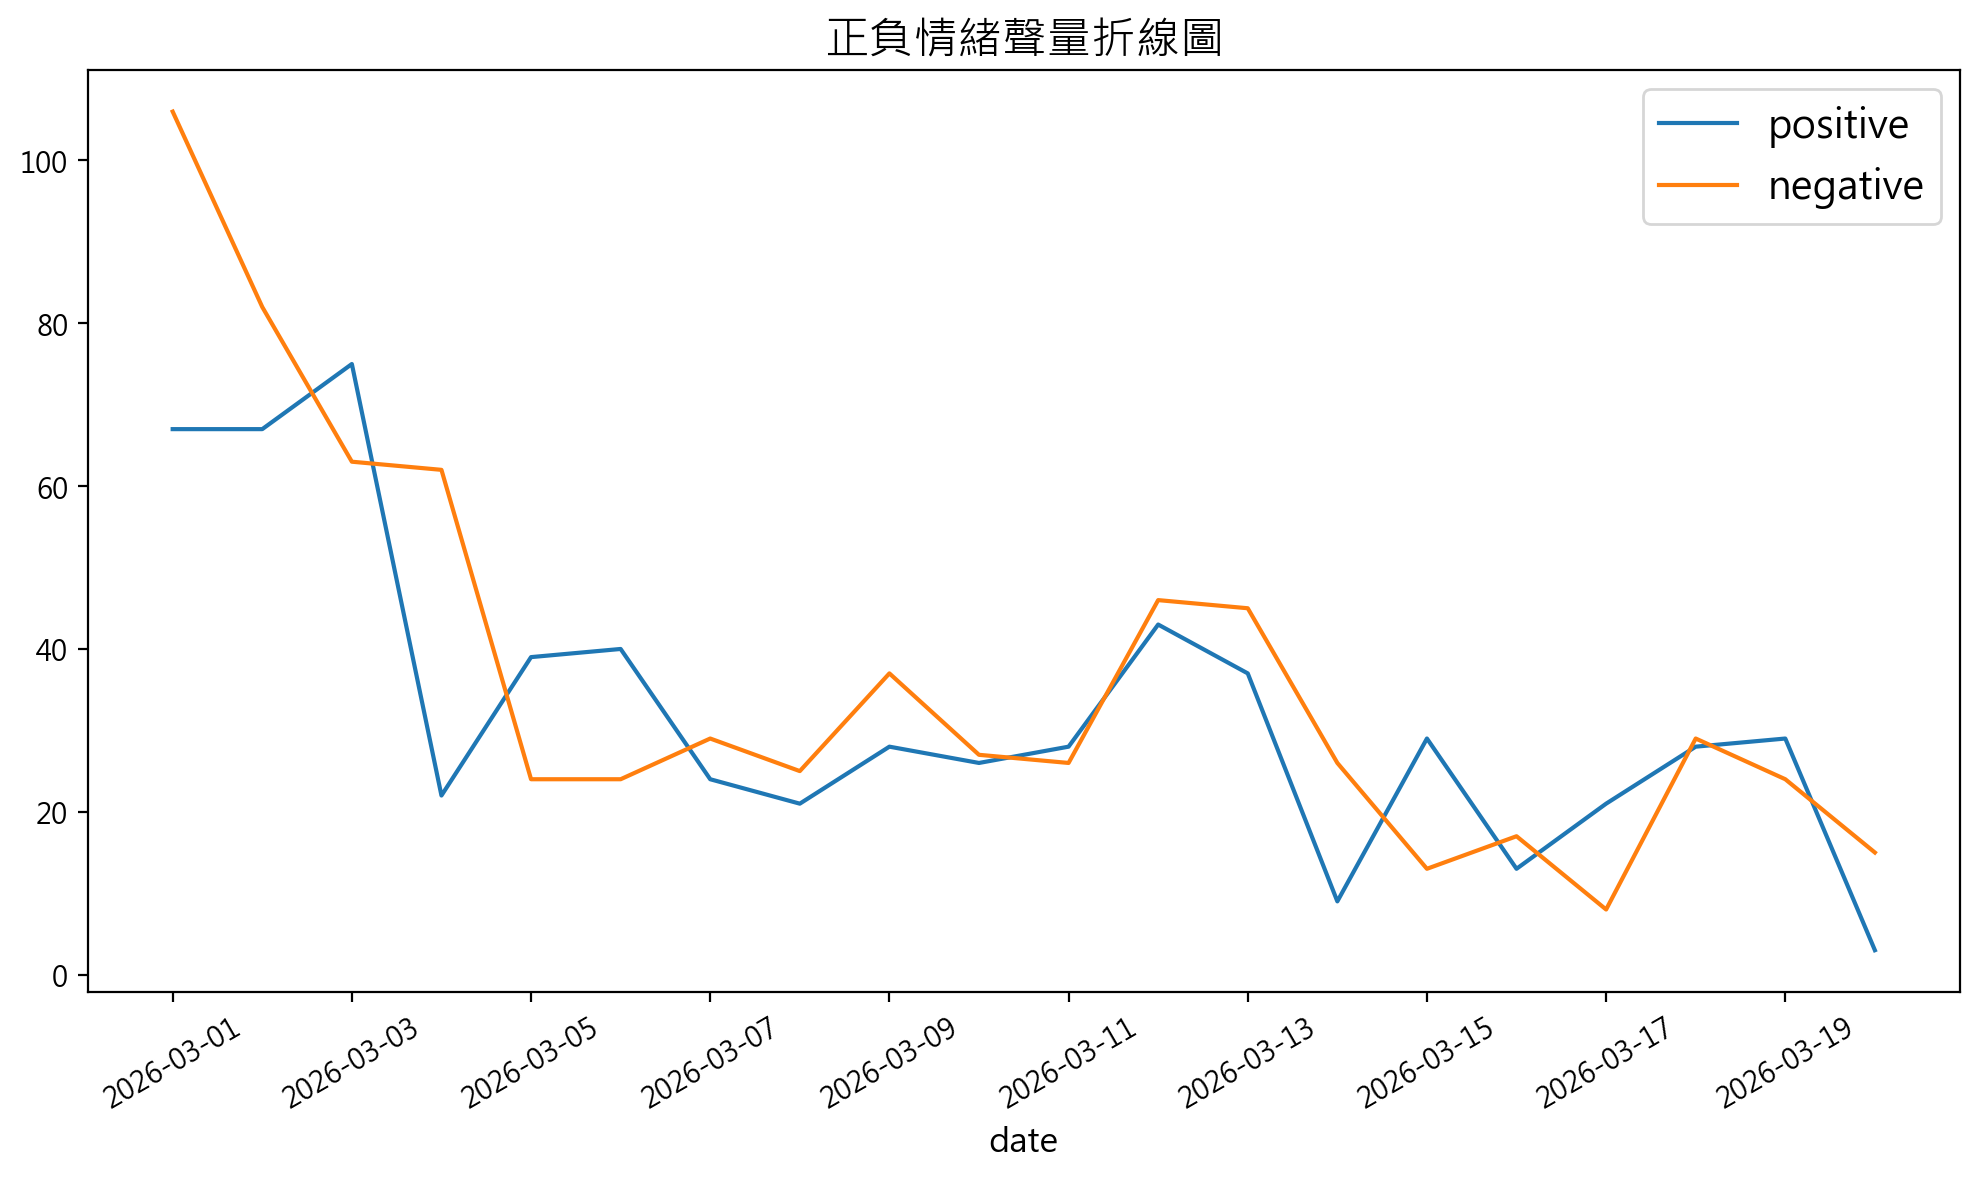

In [16]:
# 計算每天的正向與負向詞頻
df_plot = ptt_liwc_df.copy()
df_plot['artDate'] = pd.to_datetime(df_plot['artDate'])

# 建立暫時的欄位來統計次數
df_plot['pos_hits'] = (df_plot['sentiment_label'] > 0).astype(int)
df_plot['neg_hits'] = (df_plot['sentiment_label'] < 0).astype(int)

#日期聚合
daily_trend = df_plot.resample('D', on='artDate')[['pos_hits', 'neg_hits']].sum()


plt.figure(figsize=(10, 6), dpi=200)


plt.plot(daily_trend.index, daily_trend['pos_hits'], label='positive', color='#1f77b4', linewidth=1.5)


plt.plot(daily_trend.index, daily_trend['neg_hits'], label='negative', color='#ff7f0e', linewidth=1.5)


plt.title("正負情緒聲量折線圖", fontproperties=prop, fontsize=16)
plt.xlabel("date", fontproperties=prop, fontsize=12)

plt.legend(prop={'size': 14})

plt.xticks(rotation=30)
plt.grid(False)
plt.tight_layout()

plt.show()

##### 3.4 正負向情緒分析-各字詞長條圖

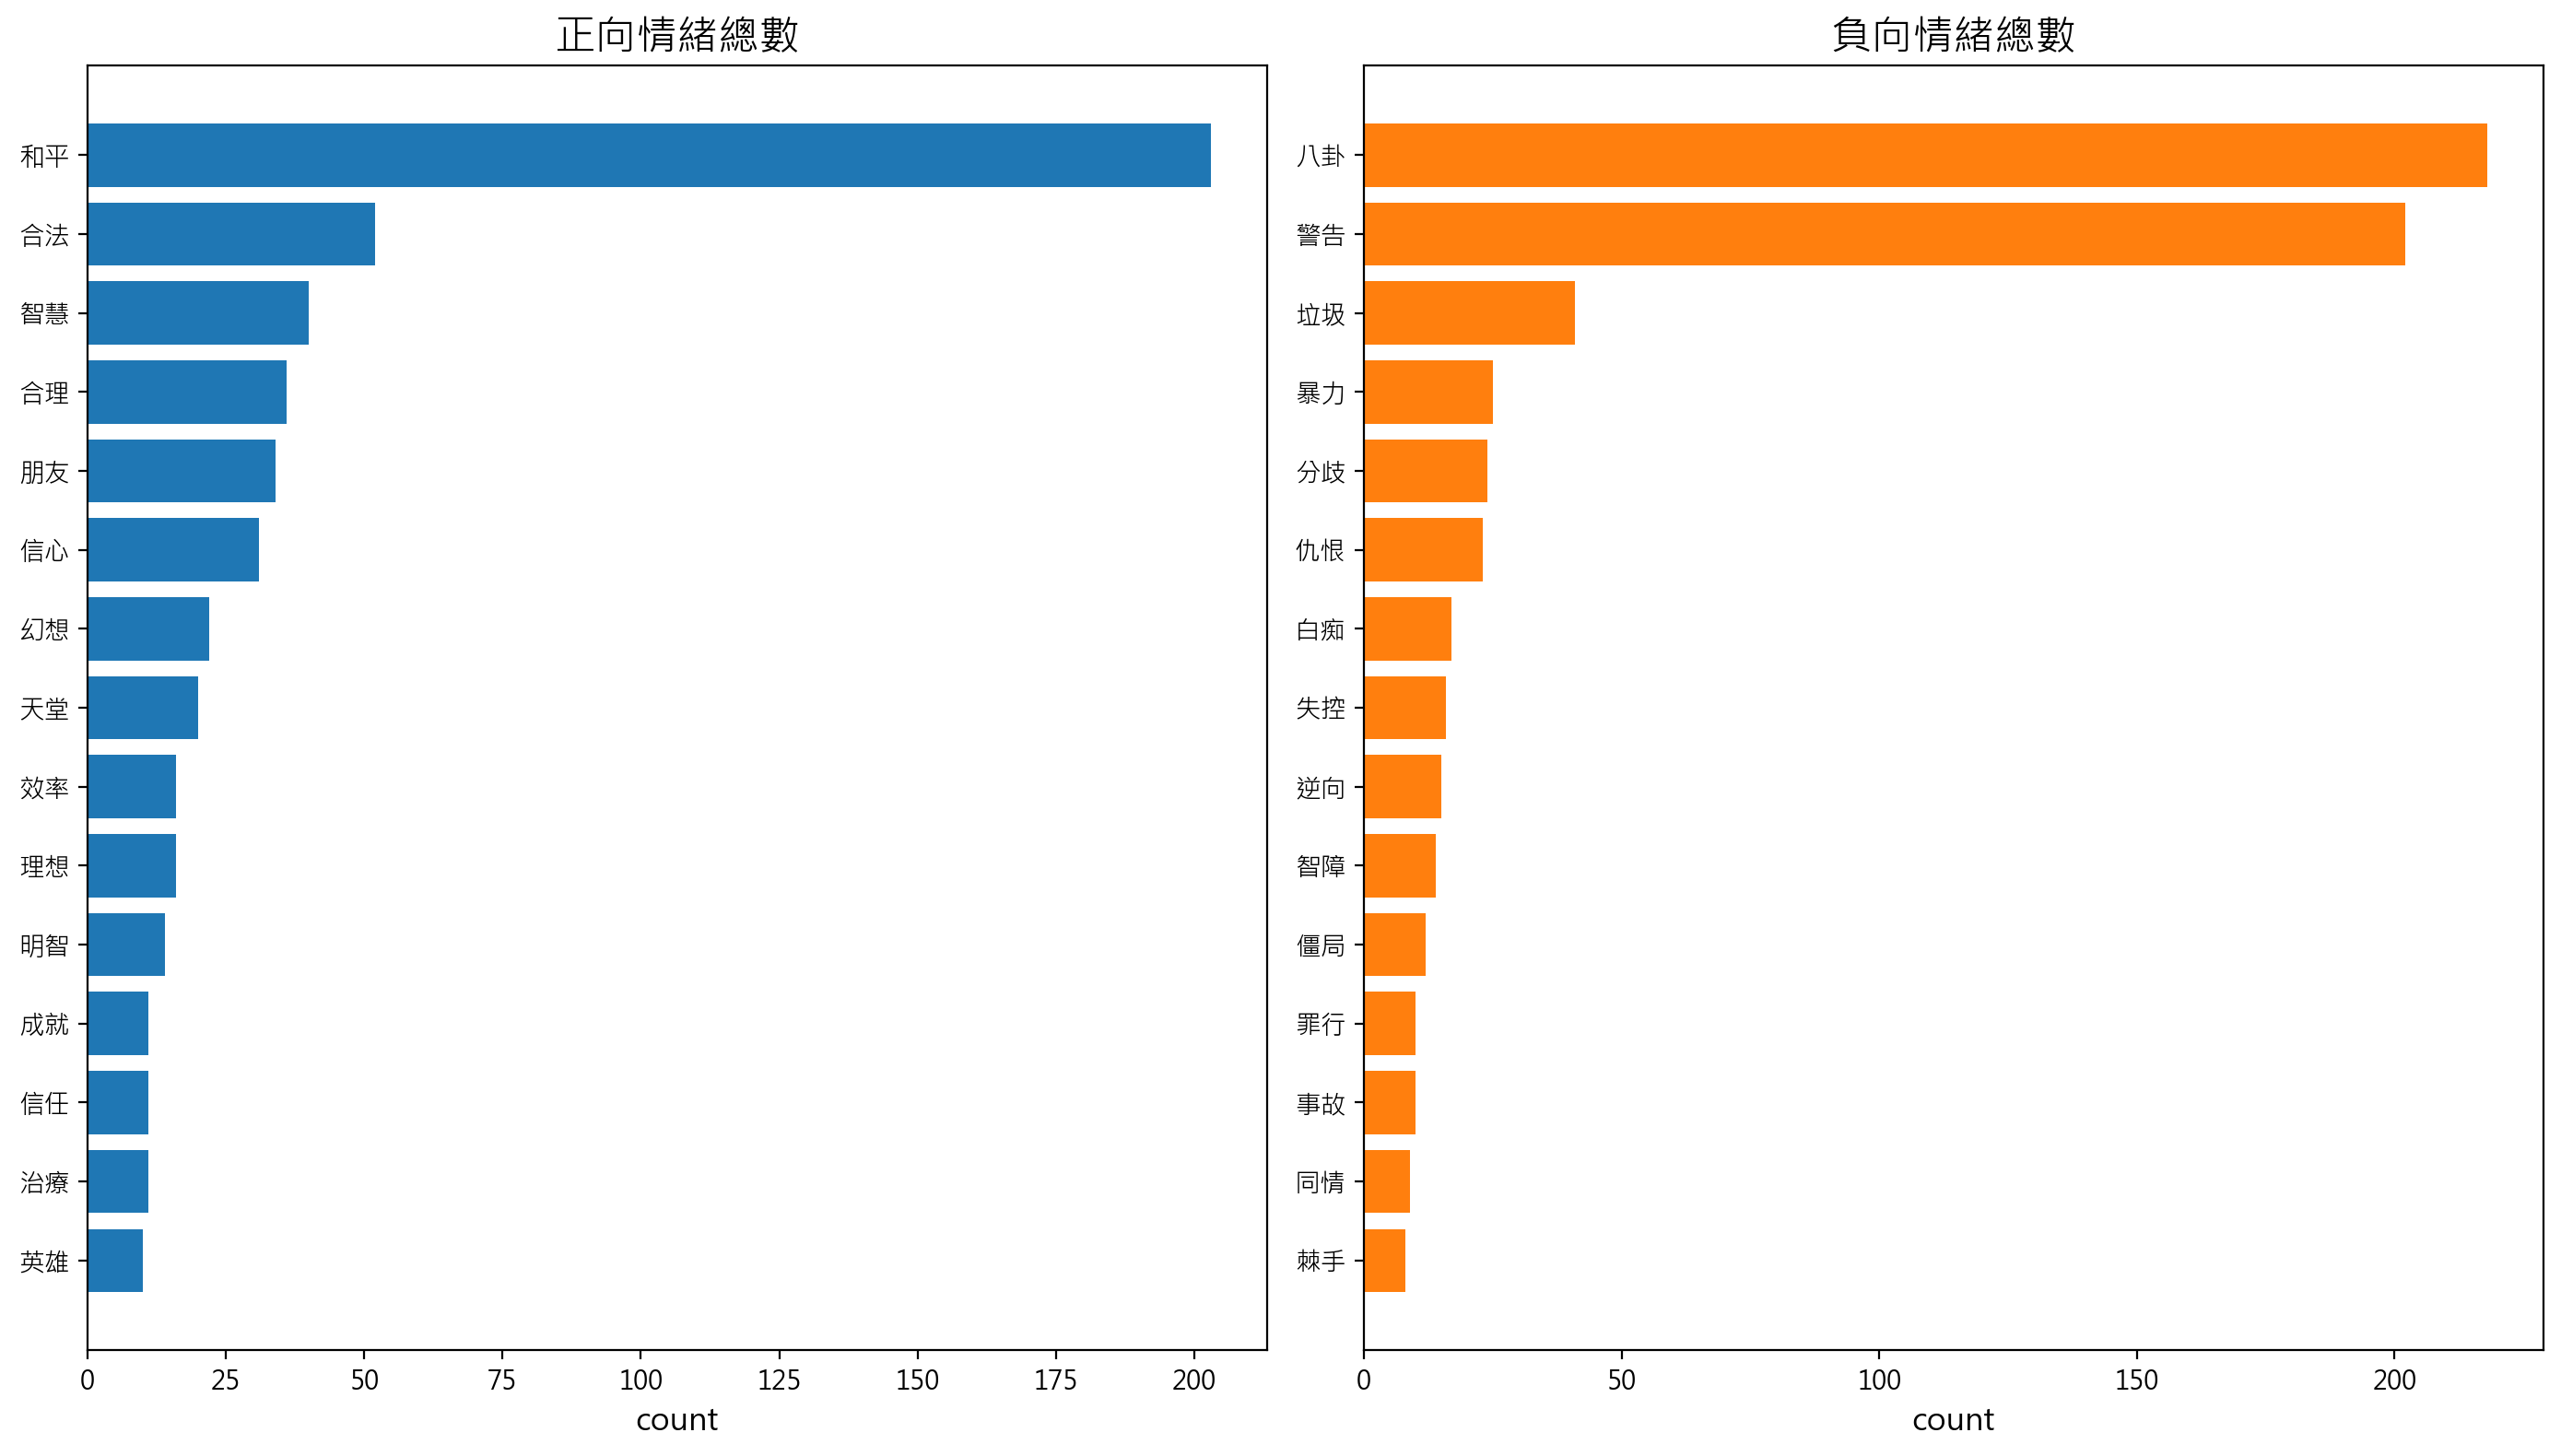

In [17]:
#篩選正向與負向詞彙，並排除標籤為 0 的中立詞
pos_data = ptt_liwc_df[ptt_liwc_df['sentiment_label'] > 0]
neg_data = ptt_liwc_df[ptt_liwc_df['sentiment_label'] < 0]

#統計詞頻
top_pos = pos_data['word'].value_counts().head(15).reset_index()
top_pos.columns = ['word', 'count']

top_neg = neg_data['word'].value_counts().head(15).reset_index()
top_neg.columns = ['word', 'count']

fig, ax = plt.subplots(1, 2, figsize=(14, 8), dpi=200)

ax[0].barh(top_pos['word'], top_pos['count'], color='#1f77b4')
ax[0].set_title('正向情緒總數', fontproperties=prop, fontsize=16)
ax[0].invert_yaxis()
ax[0].set_xlabel('count', fontsize=12)

for label in ax[0].get_yticklabels():
    label.set_fontproperties(prop)


ax[1].barh(top_neg['word'], top_neg['count'], color='#ff7f0e') # 橘色
ax[1].set_title('負向情緒總數', fontproperties=prop, fontsize=16)
ax[1].invert_yaxis()
ax[1].set_xlabel('count', fontsize=12)

for label in ax[1].get_yticklabels():
    label.set_fontproperties(prop)
plt.tight_layout()
plt.show()

##### 4.情緒分析二

##### 4.1 初始設定

In [18]:
from ckiptagger import data_utils, construct_dictionary, WS, POS, NER
import re
from wordcloud import WordCloud
import pandas as pd
import matplotlib.pyplot as plt
import time
import datetime

In [19]:
plt.rcParams['font.sans-serif'] = ['Microsoft JhengHei']

In [20]:
data_utils.download_data_gdown("../ckip_model")  # 下載ckip model

Downloading...
From (original): https://drive.google.com/uc?id=1efHsY16pxK0lBD2gYCgCTnv1Swstq771
From (redirected): https://drive.google.com/uc?id=1efHsY16pxK0lBD2gYCgCTnv1Swstq771&confirm=t&uuid=873d5a99-b456-4539-9afb-10036c6b354c
To: d:\學校東西\研究所\社媒\groupwork1\ckip_model\data.zip
100%|██████████| 1.88G/1.88G [01:39<00:00, 18.8MB/s]


In [21]:
ws = WS("../ckip_model/data")
pos = POS("../ckip_model/data")
ner = NER("../ckip_model/data")

##### 4.2 POS數量檢視

In [22]:
test_sentences = sent_df['sentence'].tolist()

#斷詞
word_list = ws(test_sentences)

#標註詞性
pos_list = pos(word_list)

pos_data = []
for i, (words, tags) in enumerate(zip(word_list, pos_list)):
    for word, tag in zip(words, tags):
        pos_data.append({
            'Sentence_ID': i,
            'Word': word,
            'POS': tag
        })

# 轉換成 DataFrame
df_pos = pd.DataFrame(pos_data)

# 顯示前 10 筆結果
df_pos.head(10)
pos_filter = df_pos[~df_pos.POS.isin(['COMMACATEGORY', 'PARENTHESISCATEGORY', 'PERIODCATEGORY', 'COLONCATEGORY'])]

pos_count = pos_filter.groupby(['POS'])['POS'].count().reset_index(name='count').sort_values(['count'], ascending=False).head(12)
pos_count

,POS,count
19,Na,99907
5,D,47398
21,Nc,45046
42,VC,37959
48,VH,24845
33,P,23165
7,DE,21707
45,VE,15811
17,FW,13535
20,Nb,12672


##### 4.3 討論風格分析

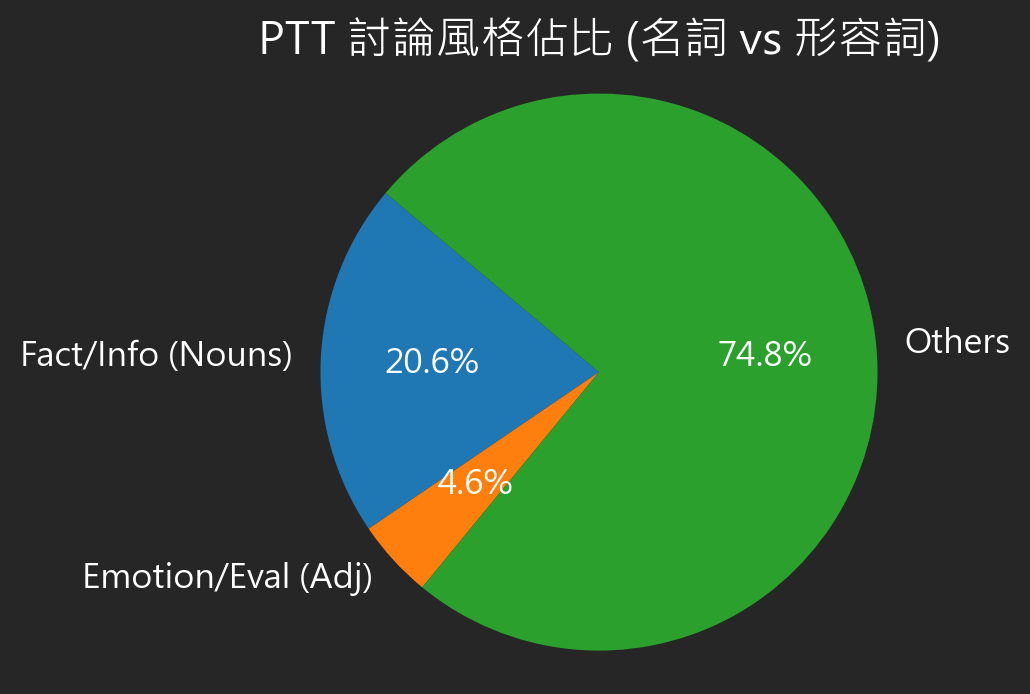

In [23]:
# Na: 普通名詞, Nb: 專有名詞
# VH: 狀態不及物動詞
noun_count = df_pos[df_pos['POS'].isin(['Na', 'Nb'])].shape[0]
adj_count = df_pos[df_pos['POS'] == 'VH'].shape[0]
other_count = df_pos.shape[0] - noun_count - adj_count


labels = ['Fact/Info (Nouns)', 'Emotion/Eval (Adj)', 'Others']
sizes = [noun_count, adj_count, other_count]
colors = ['#1f77b4', '#ff7f0e', '#2ca02c']
plt.figure(figsize=(4, 4), dpi=200, facecolor='#262626')

patches, texts, autotexts = plt.pie(
    sizes, 
    labels=labels, 
    autopct='%1.1f%%', 
    startangle=140, 
    colors=colors,
    textprops={'color': 'white', 'fontsize': 12, 'fontproperties': prop}
)

plt.title("PTT 討論風格佔比 (名詞 vs 形容詞)", fontproperties=prop, fontsize=16, color='white')
plt.axis('equal') 
plt.show()


##### 4.4 核心詞彙表

In [24]:

top_nb = df_pos[df_pos['POS'] == 'Nb']['Word'].value_counts().head(10)

top_na = df_pos[df_pos['POS'] == 'Na']['Word'].value_counts().head(10)

top_vh = df_pos[df_pos['POS'] == 'VH']['Word'].value_counts().head(10)

core_vocab_df = pd.DataFrame({
    '討論對象 (Nb)': top_nb.index,
    '討論焦點 (Na)': top_na.index,
    '感官評價 (VH)': top_vh.index
})

display(core_vocab_df)

,討論對象 (Nb),討論焦點 (Na),感官評價 (VH)
0,川普,人,大
1,哈米尼,網址,高
2,中共,文章,完整
3,伊斯蘭,戰爭,安全
4,哈梅內伊,美軍,這樣
5,北約,國家,好
6,穆吉塔巴,行動,新
7,庫德族,新聞,直接
8,共和黨,飛彈,死
9,大紀元,軍事,出現


##### 4.5 建立NER List

In [26]:
import random

ner_list = ner(word_list, pos_list)
#把所有實體攤平成一個清單
all_entities = [entity for entity_set in ner_list for entity in entity_set]

# 隨機抽出 10 個
num_to_sample = min(10, len(all_entities))
random_samples = random.sample(all_entities, num_to_sample)

#顯示結果
print(f"--- 從 {len(all_entities)} 個實體中隨機抽出 {num_to_sample} 個 ---")
for entity in random_samples:
    print(f"實體類型: {entity[2]} | 內容: {entity[3]}")

--- 從 56724 個實體中隨機抽出 10 個 ---
實體類型: GPE | 內容: 伊朗
實體類型: GPE | 內容: 美國
實體類型: CARDINAL | 內容: 一
實體類型: GPE | 內容: 台灣
實體類型: GPE | 內容: 伊朗
實體類型: GPE | 內容: 伊朗
實體類型: PERSON | 內容: 川普
實體類型: GPE | 內容: 約旦
實體類型: LOC | 內容: 亞歐
實體類型: DATE | 內容: 今天


##### 4.6 轉換成dataframe並針對人名、國家和組織分析

In [ ]:
ner_data = []
for entities in ner_list:
    for ent in entities:
        ner_data.append({'Type': ent[2], 'Entity': ent[3]})

df_ner = pd.DataFrame(ner_data)

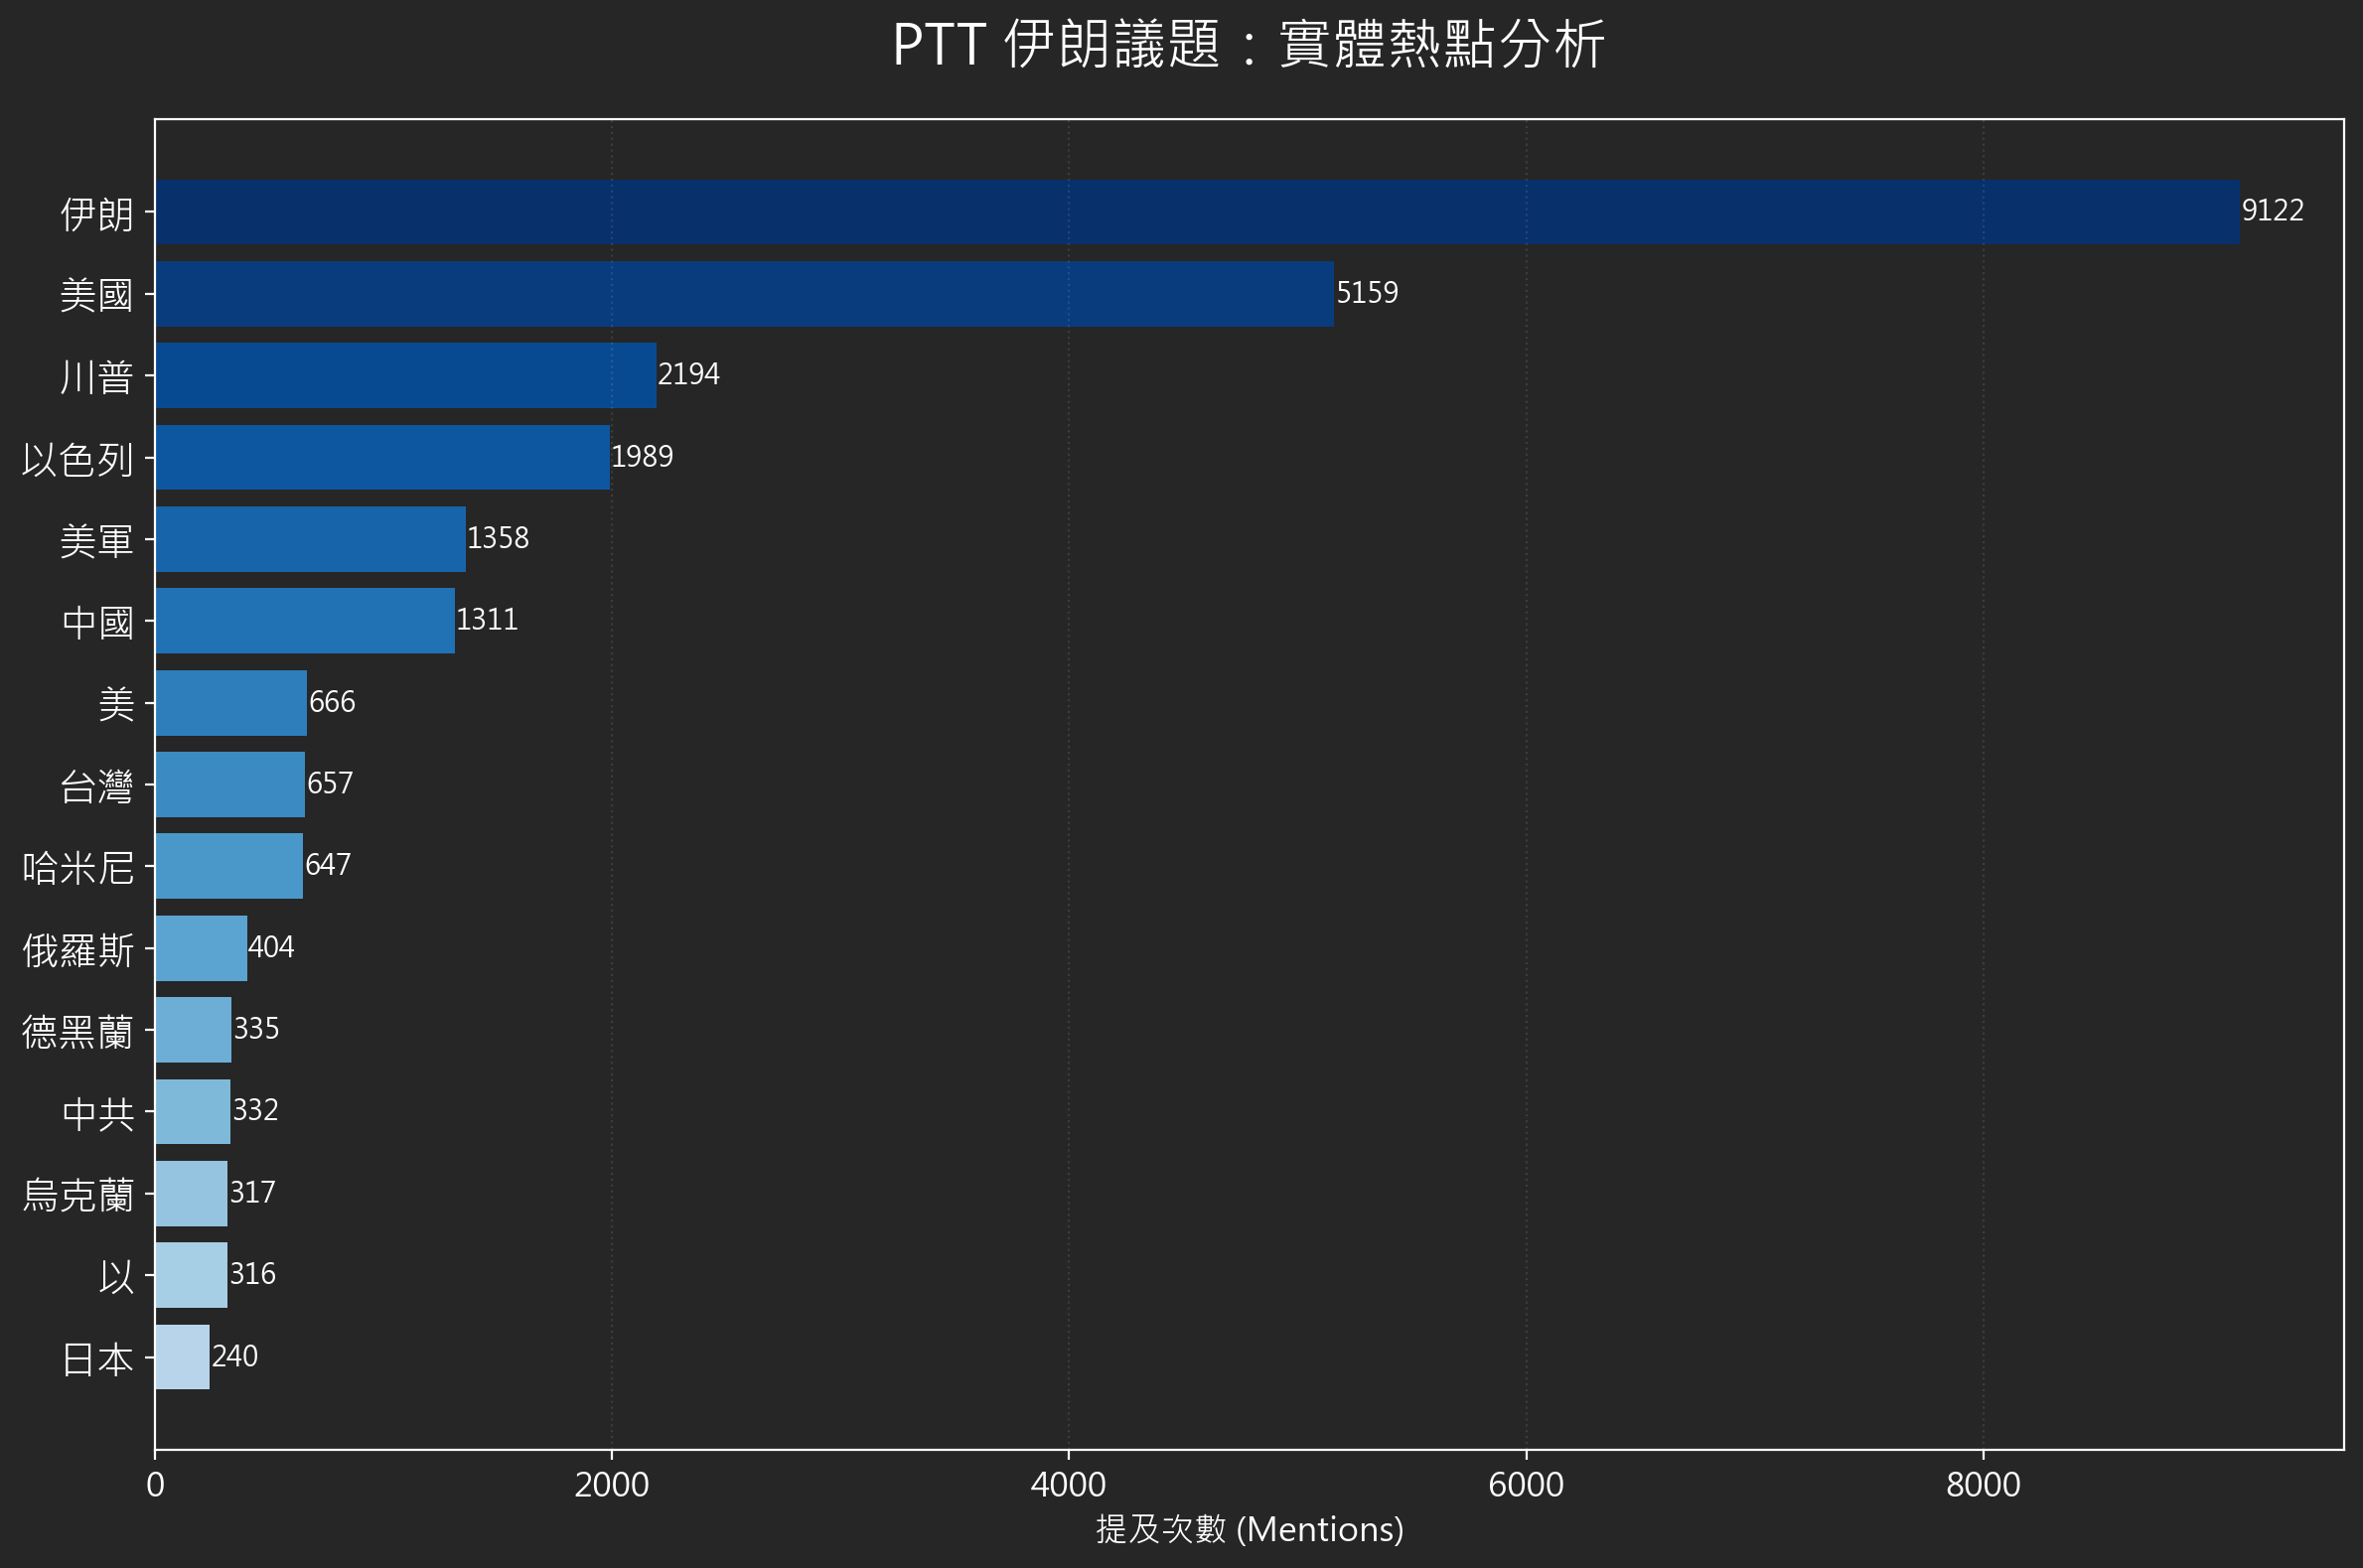

In [ ]:
import matplotlib.pyplot as plt

target_types = ['PERSON', 'GPE', 'ORG']
hotspot_df = df_ner[df_ner['Type'].isin(target_types)].copy()

#執行同義詞替換
hotspot_df['Entity'] = hotspot_df['Entity'].replace(synonyms)

#統計出現次數 Top 15
top_entities = hotspot_df['Entity'].value_counts().head(15)

plt.figure(figsize=(12, 8), dpi=200, facecolor='#262626')
ax = plt.gca()
ax.set_facecolor('#262626')

colors = plt.cm.Blues_r([i/20 for i in range(15)])
bars = plt.barh(top_entities.index, top_entities.values, color=colors)

plt.title("PTT 伊朗議題：實體熱點分析", fontproperties=prop, fontsize=20, color='white', pad=20)
plt.xlabel("提及次數 (Mentions)", color='white', fontsize=12)
plt.tick_params(colors='white', labelsize=12)

# 反轉 y 軸，讓第 1 名在上面
plt.gca().invert_yaxis()

# 設定中文字體
for label in ax.get_yticklabels():
    label.set_fontproperties(prop)
    label.set_color('white')
    label.set_fontsize(14)

# 顯示數值標籤在長條圖末端
for bar in bars:
    width = bar.get_width()
    plt.text(width + 5, bar.get_y() + bar.get_height()/2, 
             f'{int(width)}', va='center', color='white', fontsize=10)

# 修正邊框
for spine in ax.spines.values():
    spine.set_color('white')

plt.grid(axis='x', linestyle=':', alpha=0.1, color='white')
plt.tight_layout()
plt.show()

##### 4.7 計算SnowNLP分數

In [32]:
from snownlp import SnowNLP

def get_snownlp_sentiment(text):
    if not isinstance(text, str) or len(text.strip()) == 0:
        return 0.5 # 空值給中立
    try:
        s = SnowNLP(text)
        return s.sentiments
    except:
        return 0.5

# 對每一句進行情緒評分
sent_df['snownlp_score'] = sent_df['sentence'].apply(get_snownlp_sentiment)

print("--- SnowNLP 評分完成 ---")
sent_df[['sentence', 'snownlp_score']].head()

--- SnowNLP 評分完成 ---


,sentence,snownlp_score
1,報導,0.473767
2,迫降的-飛行員有破片輕傷,0.045944
3,受損的-進行硬著陸,0.085368
4,短期內不能作戰,0.103810
5,另外網路上流傳據稱是伊朗防空系統的影片,0.191478


##### 4.8 透過SnowNLP分析包含川普、哈米尼的句子

提及川普的句子數量：2636
提及哈米尼的句子數量：734


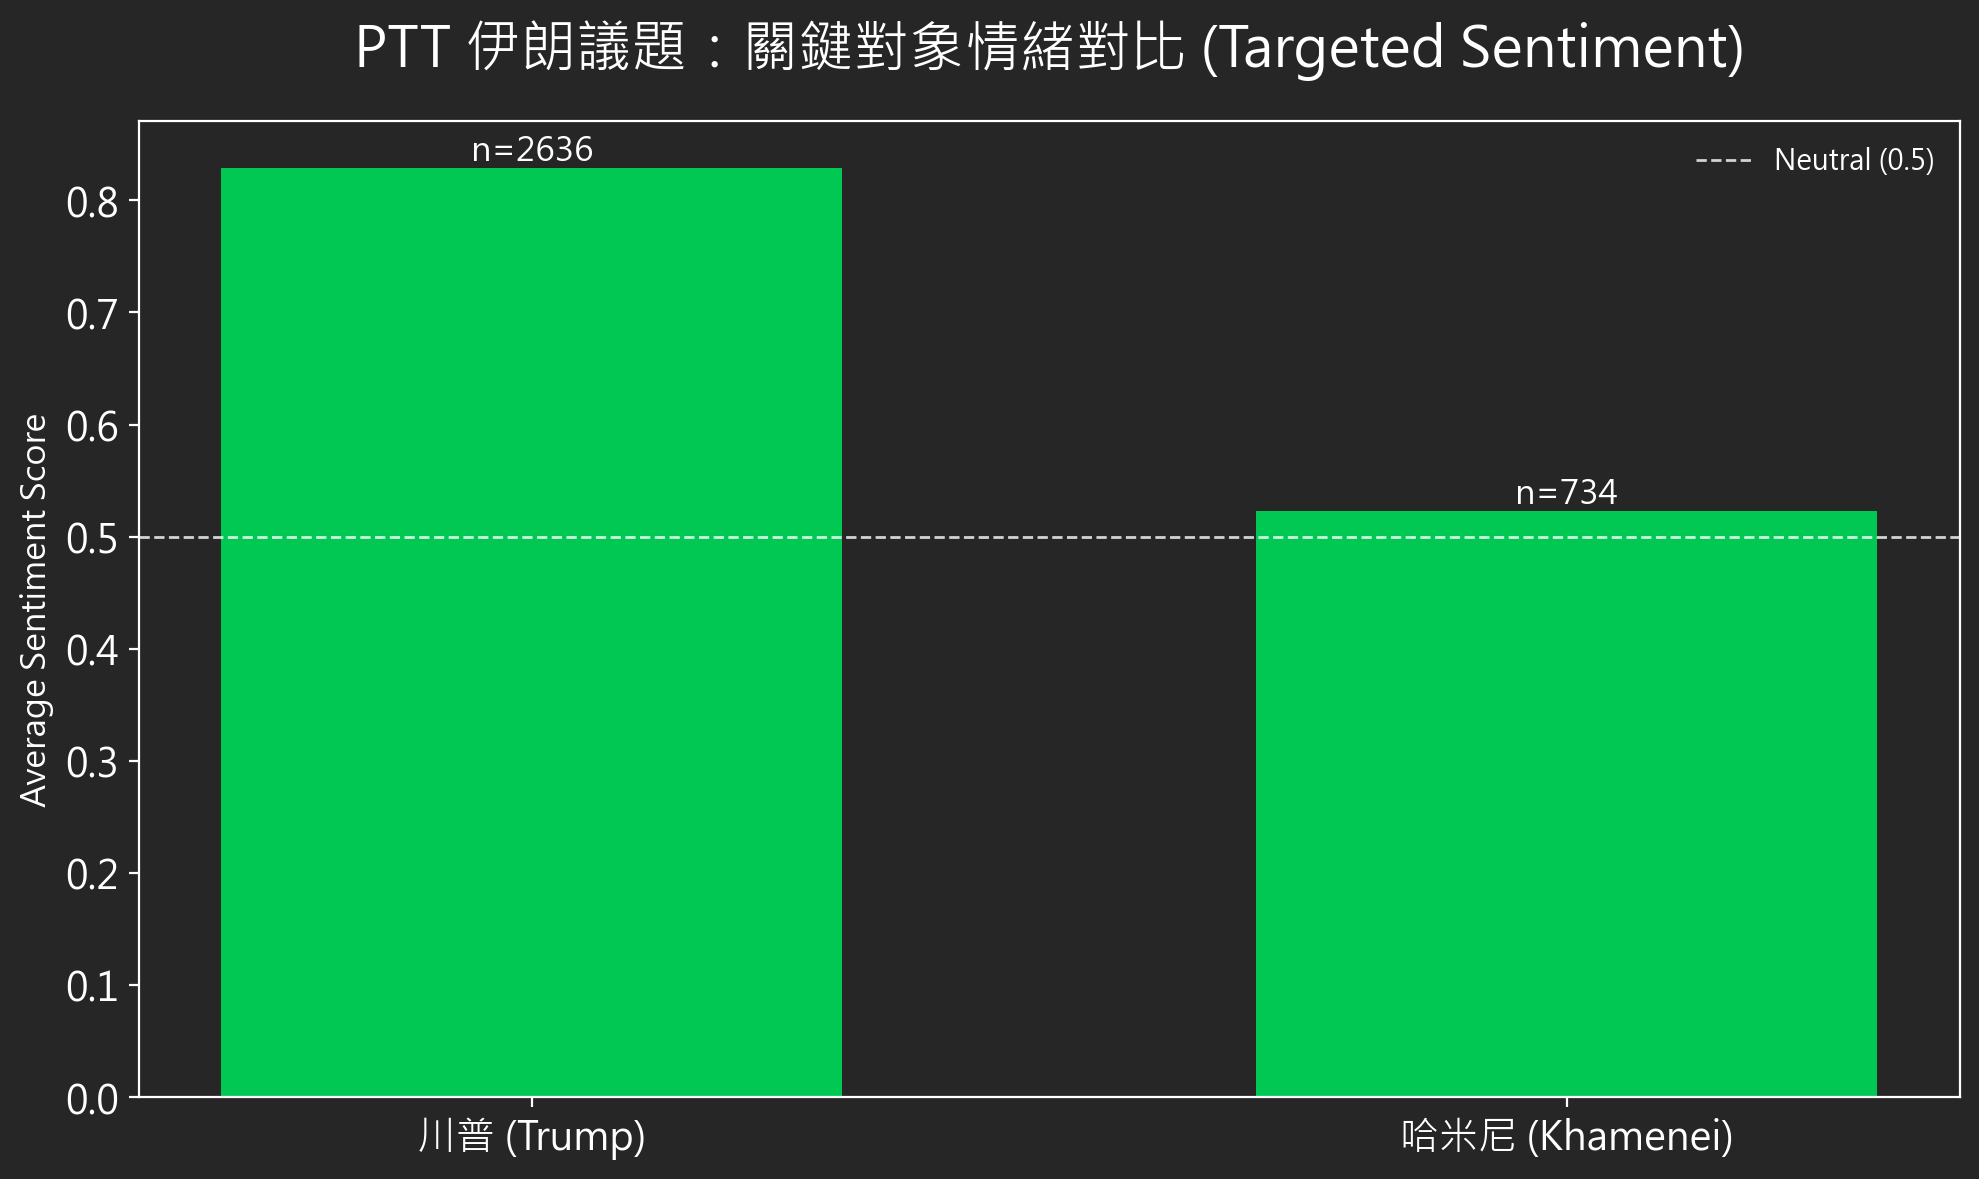

In [33]:
target_df = sent_df.copy()
# 確保句子欄位是字串型態
target_df['sentence'] = target_df['sentence'].astype(str)

#正則表達式
trump_pattern = '川普|Donald Trump|阿川|川皇'
khamenei_pattern = '哈米尼|Khamenei|哈梅內伊'

#篩選包含目標人物的句子
trump_sentences = target_df[target_df['sentence'].str.contains(trump_pattern, na=False)].copy()
khamenei_sentences = target_df[target_df['sentence'].str.contains(khamenei_pattern, na=False)].copy()

print(f"提及川普的句子數量：{len(trump_sentences)}")
print(f"提及哈米尼的句子數量：{len(khamenei_sentences)}")

#計算平均情緒分數
avg_trump_score = trump_sentences['snownlp_score'].mean()
avg_khamenei_score = khamenei_sentences['snownlp_score'].mean()

comparison_data = pd.DataFrame({
    'Entity': ['川普 (Trump)', '哈米尼 (Khamenei)'],
    'Average Sentiment (SnowNLP)': [avg_trump_score, avg_khamenei_score],
    'Mention Count': [len(trump_sentences), len(khamenei_sentences)]
})

plt.figure(figsize=(10, 6), dpi=200, facecolor='#262626')
ax = plt.gca()
ax.set_facecolor('#262626')

colors = ['#00c853' if x >= 0.5 else '#ff1744' for x in comparison_data['Average Sentiment (SnowNLP)']]

bars = plt.bar(comparison_data['Entity'], comparison_data['Average Sentiment (SnowNLP)'], color=colors, width=0.6)


plt.axhline(0.5, color='white', linewidth=1, linestyle='--', alpha=0.8, label='Neutral (0.5)')
plt.legend(prop={'size': 10}, labelcolor='white', frameon=False)

# 設定座標軸顏色為白色
plt.tick_params(colors='white', labelsize=14)
for label in ax.get_xticklabels():
    label.set_fontproperties(prop) # 設定中文字體
    label.set_fontsize(14)

# 設定標籤與標題
plt.title("PTT 伊朗議題：關鍵對象情緒對比 (Targeted Sentiment)", fontproperties=prop, fontsize=20, color='white', pad=20)
plt.ylabel("Average Sentiment Score", fontsize=12, color='white')

# 修正邊框顏色
for spine in ax.spines.values():
    spine.set_color('white')

#在長條圖上方顯示提及次數
for bar, count in zip(bars, comparison_data['Mention Count']):
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width() / 2, height,
             f'n={count}', # 顯示樣本數
             ha='center', va='bottom', color='white', fontsize=12)

plt.tight_layout()
plt.show()